In [ ]:
 
        import pandas as pd
        import numpy as np
        from sklearn.model_selection import train_test_split
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import classification_report, confusion_matrix
        from sklearn.preprocessing import LabelEncoder
        import joblib
        import matplotlib.pyplot as plt
        import seaborn as sns

        # Path to the Excel file
        file_path = r"C:\Users\Hp\OneDrive\Desktop\Excel\Projects\Telecom_2\Data & Resources\Data\Prediction_Data.xlsx"
        sheet_name = 'vw_ChurnData'

        data = pd.read_excel(file_path, sheet_name=sheet_name)

        print(data.head())


  Customer_ID  Gender  Age Married            State  Number_of_Referrals  \
0   11340-JAM  Female   21      No  Jammu & Kashmir                    8   
1   11348-MAH  Female   46      No      Maharashtra                   11   
2   11359-AND  Female   28     Yes   Andhra Pradesh                    3   
3   11370-TAM  Female   21      No       Tamil Nadu                   15   
4   11392-JAM  Female   39     Yes  Jammu & Kashmir                   11   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 7        NaN           Yes             No  ...   
1                19     Deal 3           Yes             No  ...   
2                 6     Deal 4           Yes             No  ...   
3                10     Deal 4           Yes             No  ...   
4                 1     Deal 2           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      19.950001    219.500000           0.0   
1  B

In [2]:
print(data['Gender'].unique())
print(data.dtypes['Gender'])

['Female' 'Male']
object


In [3]:
# Data Processing
# Clean column names (remove hidden spaces; replace inner spaces with underscores)
assert 'Female' in set(data['Gender']), "data is already encoded - restart and run Cell 1 first"
data.columns = data.columns.str.strip().str.replace(" ", "_")

# Remove customers who joined (outcome not known yet)
data = data[data['Customer_Status'] != 'Joined']

data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')

# Fill missing numeric values with the column median
data = data.fillna(data.median(numeric_only=True))

# Columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]


# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    data[column] = data[column].fillna('None').astype(str)
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1}).astype(int)

X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, round(y_train.mean(), 3), round(y_test.mean(), 3))


(4805, 28) (1202, 28) 0.288 0.289


In [4]:
print(label_encoders['Gender'].classes_)

['Female' 'Male']


In [ ]:
# Train random Forest Model
# Initialize Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Confusion Matrix:
[[798  57]
 [121 226]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       855
           1       0.80      0.65      0.72       347

    accuracy                           0.85      1202
   macro avg       0.83      0.79      0.81      1202
weighted avg       0.85      0.85      0.85      1202



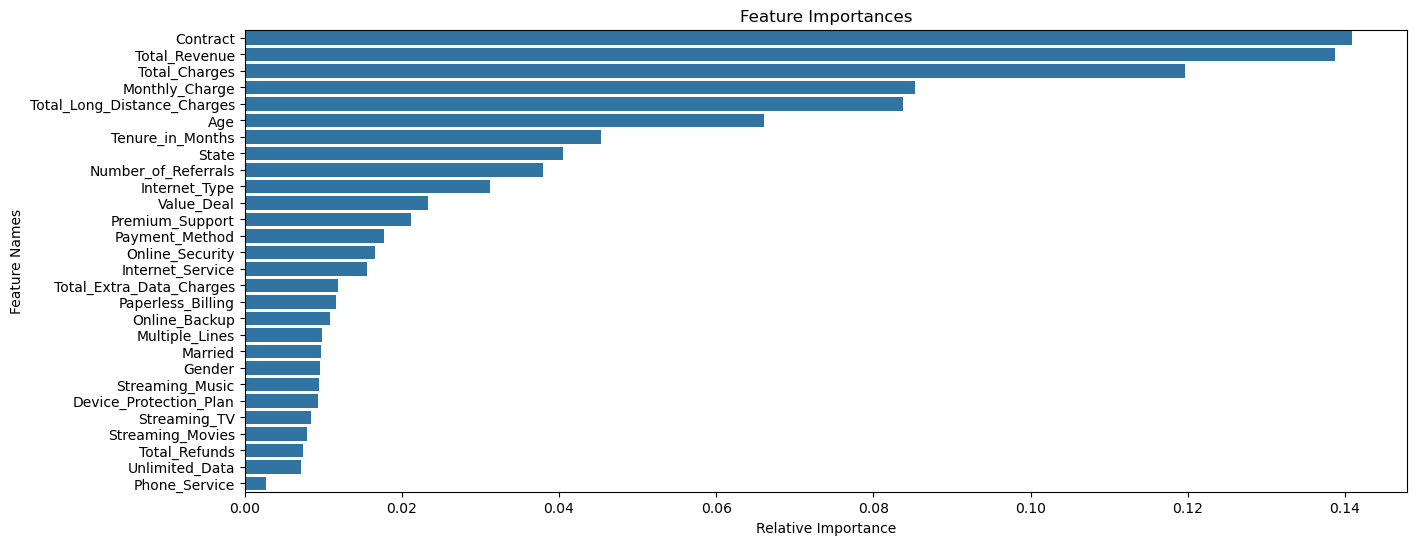

In [ ]:
# Evaluate Model for Predictions

y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot 
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()


In [7]:
print(pd.ExcelFile(file_path).sheet_names)

['vw_ChurnData', 'vw_JoinData']


In [8]:
#Predict on New Data
file_path = r"C:\Users\Hp\OneDrive\Desktop\Excel\Projects\Telecom_2\Data & Resources\Data\Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_JoinData'   

new_data = pd.read_excel(file_path, sheet_name=sheet_name)
new_data.columns = new_data.columns.str.strip().str.replace(" ", "_")   

print(new_data.head())
print(new_data.shape)   

# Original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)  

# Encode categorical variables using the saved Label encoders
for column in label_encoders:                                          
    new_data[column] = new_data[column].fillna('None').astype(str)     
    new_data[column] = label_encoders[column].transform(new_data[column])

new_data = new_data.fillna(X.median(numeric_only=True))   
new_data = new_data[X.columns]                            

# Predictions
new_predictions = rf_model.predict(new_data)
original_data['Customer_Status_Predicted'] = new_predictions

# Include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

original_data.to_excel(r"C:\Users\Hp\OneDrive\Desktop\Excel\Projects\Telecom_2\Data & Resources\Data\OutPut_Data.xlsx", index=False)  

  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   17796-BIH  Female   65      No          Bihar                    5   
1   18015-ODI  Female   28     Yes         Odisha                   15   
2   31601-DEL  Female   31     Yes          Delhi                    2   
3   32563-KAR  Female   34     Yes      Karnataka                    3   
4   32586-UTT  Female   25      No  Uttar Pradesh                   15   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 1        NaN           Yes             No  ...   
1                 9        NaN           Yes             No  ...   
2                10        NaN           Yes             No  ...   
3                22        NaN           Yes             No  ...   
4                10        NaN           Yes            Yes  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      48.450001     48.450001           0.0   
1  Bank Withdraw